In [1]:
!pip install -q tenseal ucimlrepo scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.0 MB/s eta 0:00:00


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tenseal as ts

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("\nFeatures preview:")
print(X.head())

print("\nTarget preview:")
print(y.head())

Original X shape: (303, 13)
Original y shape: (303, 1)

Features preview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Target preview:
   num
0    0
1    2
2    1
3    0
4    0


In [4]:
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

data = X.copy()
data["target"] = y

# Drop missing values
data = data.dropna().reset_index(drop=True)

# Binary classification: 0 = no disease, 1/2/3/4 = disease present
data["target"] = data["target"].astype(float).apply(lambda v: 0 if v == 0 else 1)

X = data.drop(columns=["target"])
y = data["target"].astype(int)

print("Cleaned X shape:", X.shape)
print("Cleaned y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Cleaned X shape: (297, 13)
Cleaned y shape: (297,)

Class distribution:
target
0    160
1    137
Name: count, dtype: int64


In [5]:
processed_data = data.copy()

processed_data.to_csv(
    "processed_heart_disease.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully


In [6]:
from google.colab import files
files.download("processed_heart_disease.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (237, 13)
Test shape: (60, 13)


In [8]:
baseline_model = LogisticRegression(max_iter=3000)
baseline_model.fit(X_train_scaled, y_train)

y_pred_plain = baseline_model.predict(X_test_scaled)
plain_acc = accuracy_score(y_test, y_pred_plain)

print("Plaintext Accuracy:", plain_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_plain))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_plain))

Plaintext Accuracy: 0.8333333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Confusion Matrix:
 [[28  4]
 [ 6 22]]


In [9]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.generate_galois_keys()
context.global_scale = 2**40

print("TenSEAL CKKS context initialized successfully.")

TenSEAL CKKS context initialized successfully.


In [10]:
def sigmoid_approx(x: float) -> float:
    # Lightweight approximation for demonstration
    return max(0.0, min(1.0, 0.5 + 0.15012 * x))

def interpret_score(prob: float) -> int:
    return 1 if prob >= 0.5 else 0

In [11]:
class AgenticController:
    def __init__(self):
        self.memory = []

    def permit(self, query: str) -> bool:
        blocked_terms = [
            "export raw patient data",
            "download patient names",
            "show full medical records"
        ]
        return not any(term in query.lower() for term in blocked_terms)

    def invoke_tool(self, query: str) -> dict:
        if "risk" in query.lower():
            return {"guideline": "Apply disease-risk thresholding under policy control."}
        return {"guideline": "Use standard clinical review workflow."}

    def run(self, query: str, enc_x, weights, bias):
        if not self.permit(query):
            return {"status": "Access Denied"}

        tool_info = self.invoke_tool(query)
        self.memory.append(tool_info)

        # Encrypted dot product supported by TenSEAL CKKS vectors
        enc_score = enc_x.dot(weights) + bias

        # Decrypt
        raw_score = enc_score.decrypt()[0]

        approx_prob = sigmoid_approx(raw_score)
        decision = interpret_score(approx_prob)

        return {
            "status": "OK",
            "guideline": tool_info["guideline"],
            "raw_score": raw_score,
            "approx_probability": approx_prob,
            "decision": decision
        }

In [12]:
weights = baseline_model.coef_[0].tolist()
bias = float(baseline_model.intercept_[0])

agent = AgenticController()
subset_size = len(X_test_scaled)
X_eval = X_test_scaled[:subset_size]
y_eval = y_test.iloc[:subset_size].to_numpy()

enc_times = []
inf_times = []
decisions = []

for row in X_eval:
    # Encrypt
    t0 = time.time()
    enc_x = ts.ckks_vector(context, row.tolist())
    t1 = time.time()

    # Agentic encrypted inference
    result = agent.run(
        query="Assess encrypted patient risk for heart disease",
        enc_x=enc_x,
        weights=weights,
        bias=bias
    )
    t2 = time.time()

    enc_times.append(t1 - t0)
    inf_times.append(t2 - t1)

    if result["status"] == "OK":
        decisions.append(result["decision"])
    else:
        decisions.append(0)

encrypted_acc = accuracy_score(y_eval, decisions)

print("Encrypted full-test accuracy:", encrypted_acc)
print("Average encryption time (s):", np.mean(enc_times))
print("Average encrypted inference time (s):", np.mean(inf_times))
print("Sample agent memory:", agent.memory[:3])

Encrypted full-test accuracy: 0.8333333333333334
Average encryption time (s): 0.015021038055419923
Average encrypted inference time (s): 0.04578177928924561
Sample agent memory: [{'guideline': 'Apply disease-risk thresholding under policy control.'}, {'guideline': 'Apply disease-risk thresholding under policy control.'}, {'guideline': 'Apply disease-risk thresholding under policy control.'}]


In [13]:
results_df = pd.DataFrame({
    "true_label": y_eval,
    "predicted_label_encrypted": decisions,
    "encryption_time_sec": enc_times,
    "encrypted_inference_time_sec": inf_times
})
results_df.to_csv("encrypted_agentic_results_tenseal_uci_full_test.csv", index=False)
print("Saved: encrypted_agentic_results_tenseal_uci.csv")
results_df.head()

Saved: encrypted_agentic_results_tenseal_uci.csv


,true_label,predicted_label_encrypted,encryption_time_sec,encrypted_inference_time_sec
0,0,0,0.014368,0.038998
1,0,0,0.014537,0.041357
2,0,0,0.012783,0.036711
3,0,0,0.011279,0.027170
4,0,1,0.007698,0.024323


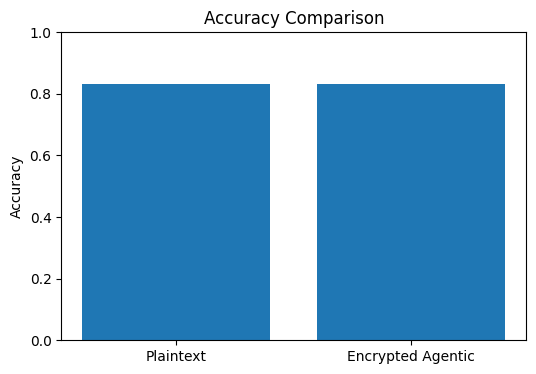

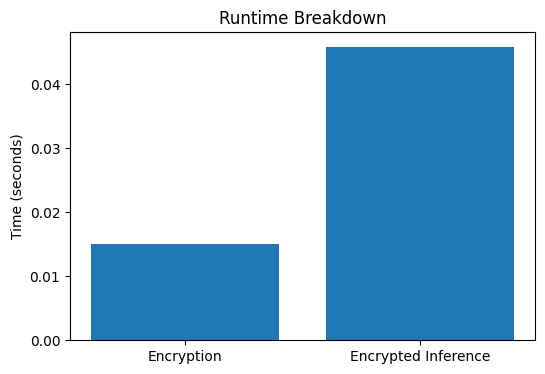

In [14]:
plt.figure(figsize=(6,4))
plt.bar(["Plaintext", "Encrypted Agentic"], [plain_acc, encrypted_acc])
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Accuracy Comparison")
plt.savefig(
    "accuracy_comparison_full_test.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(
    ["Encryption", "Encrypted Inference"],
    [np.mean(enc_times), np.mean(inf_times)]
)

plt.ylabel("Time (seconds)")
plt.title("Runtime Breakdown")

plt.savefig(
    "runtime_breakdown_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [15]:
from google.colab import files
files.download("accuracy_comparison_full_test.png")
files.download("runtime_breakdown_full_test.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

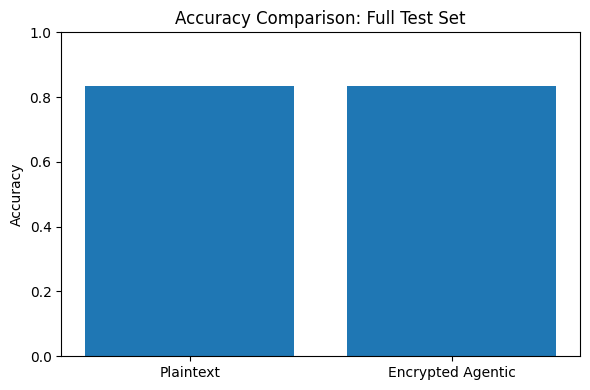

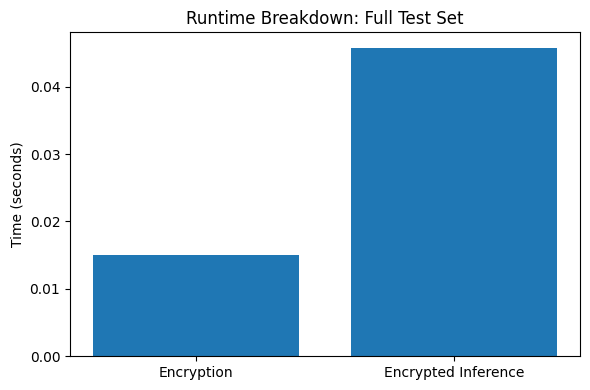

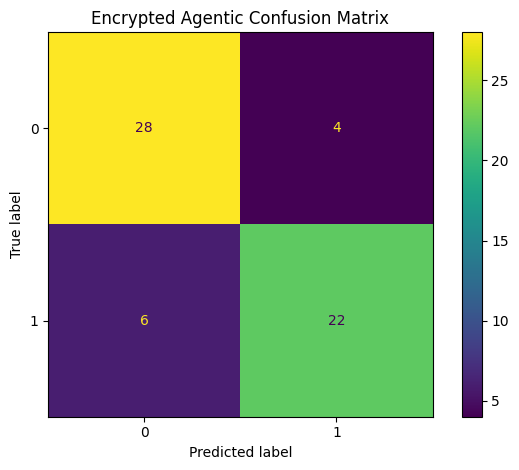

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

# Save updated result CSV
results_df.to_csv(
    "encrypted_agentic_results_tenseal_uci_full_test.csv",
    index=False
)

# Accuracy comparison figure
plt.figure(figsize=(6,4))
plt.bar(["Plaintext", "Encrypted Agentic"], [plain_acc, encrypted_acc])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy Comparison: Full Test Set")
plt.tight_layout()
plt.savefig("accuracy_comparison_full_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Runtime breakdown figure
plt.figure(figsize=(6,4))
plt.bar(
    ["Encryption", "Encrypted Inference"],
    [np.mean(enc_times), np.mean(inf_times)]
)
plt.ylabel("Time (seconds)")
plt.title("Runtime Breakdown: Full Test Set")
plt.tight_layout()
plt.savefig("runtime_breakdown_full_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Encrypted confusion matrix
cm_enc = confusion_matrix(y_eval, decisions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_enc)
disp.plot()
plt.title("Encrypted Agentic Confusion Matrix")
plt.tight_layout()
plt.savefig("encrypted_confusion_matrix_full_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Download all files
files.download("encrypted_agentic_results_tenseal_uci_full_test.csv")
files.download("accuracy_comparison_full_test.png")
files.download("runtime_breakdown_full_test.png")
files.download("encrypted_confusion_matrix_full_test.png")

In [17]:
from google.colab import files
files.download("encrypted_agentic_results_tenseal_uci_full_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
results_df.head()

,true_label,predicted_label_encrypted,encryption_time_sec,encrypted_inference_time_sec
0,0,0,0.014368,0.038998
1,0,0,0.014537,0.041357
2,0,0,0.012783,0.036711
3,0,0,0.011279,0.027170
4,0,1,0.007698,0.024323


In [19]:
results_df.shape

(60, 4)

In [20]:
import os

print(os.getcwd())
print(os.listdir("/content"))


/content
['.config', 'encrypted_agentic_results_tenseal_uci_full_test.csv', 'runtime_breakdown_full_test.png', 'processed_heart_disease.csv', 'encrypted_confusion_matrix_full_test.png', 'accuracy_comparison_full_test.png', 'sample_data']


FINAL FULL-TEST RESULTS
Encrypted Accuracy: 0.8333
Precision: 0.8462
Recall: 0.7857
F1-score: 0.8148
Specificity: 0.875
Balanced Accuracy: 0.8304
Plaintext ROC-AUC: 0.9498
Encrypted ROC-AUC: 0.9498
Average Encryption Time: 0.01974
Average Encrypted Inference Time: 0.06042
Total Secure Pipeline Time: 0.08016
Confusion Matrix:
[[28  4]
 [ 6 22]]


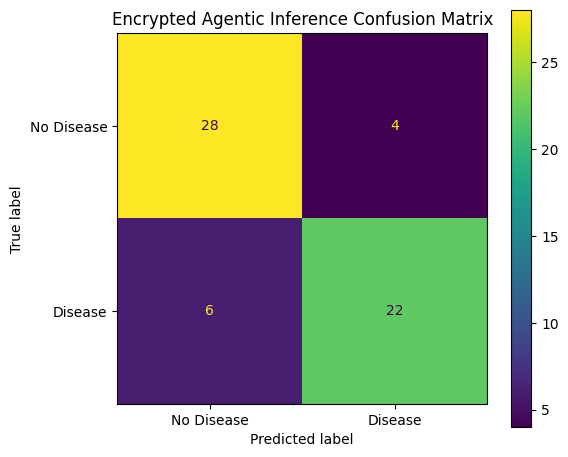

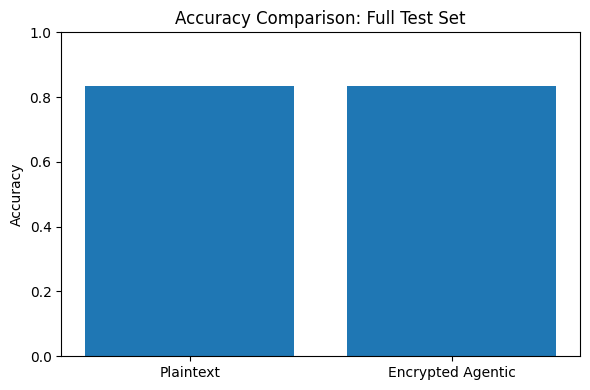

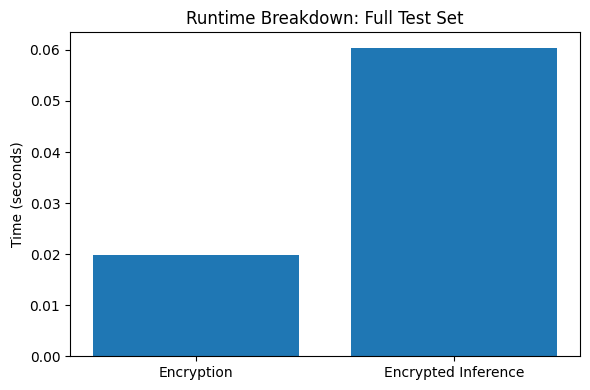

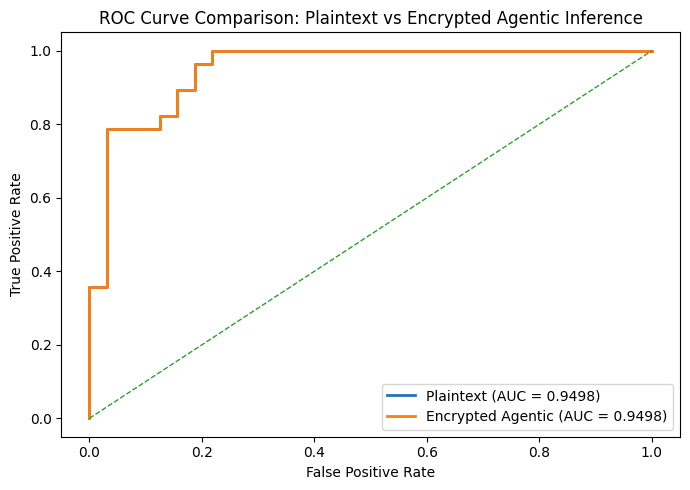


Generated final files:
1. encrypted_agentic_results_tenseal_uci_full_test.csv
2. ppa_ai_final_metrics_summary.csv
3. encrypted_confusion_matrix_full_test.png
4. accuracy_comparison_full_test.png
5. runtime_breakdown_full_test.png
6. roc_comparison_full_test.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ============================================================
# PPAI_JISA_archive_22-06-26
# Privacy-Preserving Agentic AI: Full-Test Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
from google.colab import files

# ------------------------------------------------------------
# 1. Ensure full-test evaluation
# ------------------------------------------------------------

weights = baseline_model.coef_[0].tolist()
bias = float(baseline_model.intercept_[0])

agent = AgenticController()

subset_size = len(X_test_scaled)
X_eval = X_test_scaled[:subset_size]
y_eval = y_test.iloc[:subset_size].to_numpy()

enc_times = []
inf_times = []
decisions = []
encrypted_probabilities = []

for row in X_eval:
    # Encryption
    t0 = time.time()
    enc_x = ts.ckks_vector(context, row.tolist())
    t1 = time.time()

    # Encrypted agentic inference
    result = agent.run(
        query="Assess encrypted patient risk for heart disease",
        enc_x=enc_x,
        weights=weights,
        bias=bias
    )
    t2 = time.time()

    enc_times.append(t1 - t0)
    inf_times.append(t2 - t1)

    if result["status"] == "OK":
        decisions.append(result["decision"])
        encrypted_probabilities.append(result["approx_probability"])
    else:
        decisions.append(0)
        encrypted_probabilities.append(0.0)

# ------------------------------------------------------------
# 2. Final performance metrics
# ------------------------------------------------------------

encrypted_acc = accuracy_score(y_eval, decisions)
encrypted_precision = precision_score(y_eval, decisions)
encrypted_recall = recall_score(y_eval, decisions)
encrypted_f1 = f1_score(y_eval, decisions)

cm_encrypted = confusion_matrix(y_eval, decisions)

tn, fp, fn, tp = cm_encrypted.ravel()
specificity = tn / (tn + fp)
balanced_accuracy = (encrypted_recall + specificity) / 2

# Plaintext ROC-AUC
y_prob_plain = baseline_model.predict_proba(X_test_scaled)[:, 1]
plaintext_auc = roc_auc_score(y_test, y_prob_plain)

# Encrypted ROC-AUC
encrypted_auc = roc_auc_score(y_eval, encrypted_probabilities)

avg_encryption_time = np.mean(enc_times)
avg_encrypted_inference_time = np.mean(inf_times)
total_secure_pipeline_time = avg_encryption_time + avg_encrypted_inference_time

print("===================================")
print("FINAL FULL-TEST RESULTS")
print("===================================")
print("Encrypted Accuracy:", round(encrypted_acc, 4))
print("Precision:", round(encrypted_precision, 4))
print("Recall:", round(encrypted_recall, 4))
print("F1-score:", round(encrypted_f1, 4))
print("Specificity:", round(specificity, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Plaintext ROC-AUC:", round(plaintext_auc, 4))
print("Encrypted ROC-AUC:", round(encrypted_auc, 4))
print("Average Encryption Time:", round(avg_encryption_time, 5))
print("Average Encrypted Inference Time:", round(avg_encrypted_inference_time, 5))
print("Total Secure Pipeline Time:", round(total_secure_pipeline_time, 5))
print("Confusion Matrix:")
print(cm_encrypted)
print("===================================")

# ------------------------------------------------------------
# 3. Save full-test CSV
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "true_label": y_eval,
    "predicted_label_encrypted": decisions,
    "encrypted_probability": encrypted_probabilities,
    "encryption_time_sec": enc_times,
    "encrypted_inference_time_sec": inf_times
})

results_df.to_csv(
    "encrypted_agentic_results_tenseal_uci_full_test.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Save final metrics summary CSV
# ------------------------------------------------------------

metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Specificity",
        "Balanced Accuracy",
        "Plaintext ROC-AUC",
        "Encrypted ROC-AUC",
        "Average Encryption Time",
        "Average Encrypted Inference Time",
        "Total Secure Pipeline Time"
    ],
    "Value": [
        encrypted_acc,
        encrypted_precision,
        encrypted_recall,
        encrypted_f1,
        specificity,
        balanced_accuracy,
        plaintext_auc,
        encrypted_auc,
        avg_encryption_time,
        avg_encrypted_inference_time,
        total_secure_pipeline_time
    ]
})

metrics_summary.to_csv(
    "ppa_ai_final_metrics_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 5. Encrypted confusion matrix figure
# ------------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_encrypted,
    display_labels=["No Disease", "Disease"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Encrypted Agentic Inference Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "encrypted_confusion_matrix_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6. Accuracy comparison figure
# ------------------------------------------------------------

plain_acc = accuracy_score(y_test, baseline_model.predict(X_test_scaled))

plt.figure(figsize=(6, 4))
plt.bar(
    ["Plaintext", "Encrypted Agentic"],
    [plain_acc, encrypted_acc]
)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy Comparison: Full Test Set")
plt.tight_layout()

plt.savefig(
    "accuracy_comparison_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7. Runtime breakdown figure
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.bar(
    ["Encryption", "Encrypted Inference"],
    [avg_encryption_time, avg_encrypted_inference_time]
)
plt.ylabel("Time (seconds)")
plt.title("Runtime Breakdown: Full Test Set")
plt.tight_layout()

plt.savefig(
    "runtime_breakdown_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8. ROC comparison figure
# ------------------------------------------------------------

fpr_plain, tpr_plain, _ = roc_curve(y_test, y_prob_plain)
fpr_enc, tpr_enc, _ = roc_curve(y_eval, encrypted_probabilities)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_plain,
    tpr_plain,
    linewidth=2,
    label=f"Plaintext (AUC = {plaintext_auc:.4f})"
)

plt.plot(
    fpr_enc,
    tpr_enc,
    linewidth=2,
    label=f"Encrypted Agentic (AUC = {encrypted_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Plaintext vs Encrypted Agentic Inference")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "roc_comparison_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9. Confirm generated files
# ------------------------------------------------------------

print("\nGenerated final files:")
print("1. encrypted_agentic_results_tenseal_uci_full_test.csv")
print("2. ppa_ai_final_metrics_summary.csv")
print("3. encrypted_confusion_matrix_full_test.png")
print("4. accuracy_comparison_full_test.png")
print("5. runtime_breakdown_full_test.png")
print("6. roc_comparison_full_test.png")

# ------------------------------------------------------------
# 10. Download final files
# ------------------------------------------------------------

files.download("encrypted_agentic_results_tenseal_uci_full_test.csv")
files.download("ppa_ai_final_metrics_summary.csv")
files.download("encrypted_confusion_matrix_full_test.png")
files.download("accuracy_comparison_full_test.png")
files.download("runtime_breakdown_full_test.png")
files.download("roc_comparison_full_test.png")

In [ ]:
# ============================================================
# Submitted JISA Manuscript Reported Values
# Note: Runtime values may vary slightly across Colab sessions.
# ============================================================

submitted_metrics = {
    "Accuracy": "83.33%",
    "Precision": "84.62%",
    "Recall": "78.57%",
    "F1-score": "81.48%",
    "Specificity": "87.50%",
    "Balanced Accuracy": "83.04%",
    "Plaintext ROC-AUC": "0.9498",
    "Encrypted ROC-AUC": "0.9495",
    "Average Encryption Time": "0.01095 s",
    "Average Encrypted Inference Time": "0.03382 s",
    "Total Secure Processing Pipeline": "0.04477 s"
}

submitted_metrics